# Player Tracking in Sports - Multi-View Tracking and 3D Reconstruction

The problem we are addressing is to reliably **detecting and maintaining consistent identities for players and the ball** across multiple synchronized camera views.
Then, from the multi-view tracking results, we aim to perform **3D reconstruction** of player and ball positions, thanks to the multi-view geometry and camera calibration data.

Through different approaches, we aim to solve this problem, achieving accurate and robust tracking and reconstruction results.


---

### Imports

In [1]:
import sys
from pathlib import Path
# Add the parent directory to the system path to allow imports from there
sys.path.insert(0, str(Path.cwd().parent))

In [2]:
from src.utils.video_io import stream_frame_chunks

from src.visualization.image_viewer import show_images
from src.visualization.eval_tables import show_detection_table, show_identity_table, show_hota_table, show_trajectory_table, show_reprojection_table
from src.visualization.scene_3d import show_3d_scene_frames

from src.detection.yolo.model import load_fine_tuned_yolo_model
from src.utils.annotations.download_annotations import download_annotations
from src.utils.annotations.load_annotations import load_annotations

from src.types.detection import DetectionOutput, FrameDetections, merge_detections
from src.types.tracking import TrackingOutput

from src.detection.image_processing import make_clahe, make_morph_kernel
from src.detection.mog2_detection import step_mog2, mog2_frame_to_detections
from src.detection.yolo.detection import run_yolo_detection, yolo_to_detection_output
from src.tracking.sort import apply_sort
from src.tracking.deep_sort import build_deep_sort_tracker, step_deep_sort
from src.tracking.trajectory_smoothing import smooth_tracking_output
from src.detection.nms import class_independent_nms
from src.tracking.label_resolution import resolve_track_labels

from src.evaluation.evaluate_tracking import evaluate_tracking
from src.evaluation.evaluate_detection import evaluate_detection
from src.evaluation.evaluate_geometry import evaluate_geometry

from src.calibration.camera_data import CameraData
from src.config import get_config
from src.geometry.rectification import rectify_tracking_output
from src.geometry.triangulation import triangulate_rectified_outputs
from src.geometry.smoothing import smooth_triangulation
from src.paths import CameraPaths
from src.paths.camera_paths import DEFAULT_ANNOTATIONS_VERSION
from src.paths.defaults import (
    DEFAULT_ANNOTATIONS_DIR,
    DEFAULT_CAMERA_DATA_DIR,
    DEFAULT_MODELS_DIR,
    DEFAULT_VIDEOS_INPUT_DIR,
 )
from src.paths.model_paths import YOLO_FINE_TUNED_DIR

from src.utils.logging import configure_logging, get_logger

from collections import defaultdict
import cv2
import os
from dotenv import load_dotenv
from ultralytics import YOLO

configure_logging()
logger = get_logger("notebook")

### Global Parameters

Global parameter variables configure experiment scope and file locations, enabling quick tests, dataset/model switching, and evaluation-scope changes without modifying implementation.

In [3]:
INSPECT_CAMERA_ID = "cam_13"                                # The camera we will inspect in detail in the notebook
FRAME_STRIDE = 5                                            # Step between GT annotation frames and prediction frame indices
MAX_FRAMES   = None                                         # Frames to process per camera (None = all frames)
CHUNK_SIZE   = 128                                          # Frames decoded into RAM at a time (lower = less peak RAM)

VIDEOS_INPUT_DIR = DEFAULT_VIDEOS_INPUT_DIR                # Directory where the input videos are stored
CAMERA_DATA_DIR   = DEFAULT_CAMERA_DATA_DIR                 # Directory where the camera settings JSON files are stored
MODELS_DIR        = DEFAULT_MODELS_DIR                      # Directory where pretrained and fine-tuned models are stored
FINE_TUNED_MODELS_DIR = YOLO_FINE_TUNED_DIR                 # Directory where fine-tuned models will be saved
ANNOTATIONS_DIR   = DEFAULT_ANNOTATIONS_DIR                 # Root directory for tracking annotations
ANNOTATIONS_VERSION = DEFAULT_ANNOTATIONS_VERSION           # Subdirectory version under annotations root

# Define fundamental paths for each camera
CAMERAS = {
    cam_id: CameraPaths.for_camera(
        cam_id,
        videos_input_dir=VIDEOS_INPUT_DIR,
        camera_data_dir=CAMERA_DATA_DIR,
    )
    for cam_id in ("cam_13", "cam_2", "cam_4")
}

### Open Video and Read Frames

Load the synchronized multi-camera video recordings of a basketball game captured at the **Sanbapolis facility** in Trento, Italy. These are the source videos used for all subsequent processing and evaluation.

All videos capture a single game act and were recorded at 25 frames per second (25 fps).



In [4]:
# Probe each camera's video for fps and total frame count without decoding all frames.
fps = {}
total_frames_per_cam = {}
for cam_id, cam in CAMERAS.items():
    cap = cv2.VideoCapture(str(cam.video))
    fps[cam_id] = cap.get(cv2.CAP_PROP_FPS)
    # If MAX_FRAMES is set, we will only process up to that many frames per camera
    nf = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    # Release the video capture immediately since we will reopen it later for actual frame processing. We just wanted the metadata here.
    cap.release()

    # Log the total frames available and fps for each camera
    total_frames_per_cam[cam_id] = nf if MAX_FRAMES is None else min(nf, MAX_FRAMES)
    logger.info("[%s] %d frames available at %.1f fps", cam_id, total_frames_per_cam[cam_id], fps[cam_id])

01:02:01 | INFO | notebook | [cam_13] 525 frames available at 25.0 fps
01:02:01 | INFO | notebook | [cam_2] 525 frames available at 25.0 fps
01:02:02 | INFO | notebook | [cam_4] 525 frames available at 25.0 fps


We provide also a utility function to **inspect the videos** by displaying only a few frames from the selected cameras. In order to avoid saturating the RAM, we use `stream_frame_chunks` that reads the video in small chunks of frames, yielding one chunk at a time. 

In [5]:
# For inspecting the videos, we will select 3 frames from the inspect camera
_inspect_n = total_frames_per_cam[INSPECT_CAMERA_ID]
INSPECT_INDEXES = [0, _inspect_n // 2, _inspect_n - 1]
inspect_frames = {}
for start, chunk in stream_frame_chunks(
    CAMERAS[INSPECT_CAMERA_ID].video,
    chunk_size=CHUNK_SIZE,
    max_frames=_inspect_n,
    ):
    for offset, frame in enumerate(chunk):
        fi = start + offset
        if fi in INSPECT_INDEXES:
            inspect_frames[fi] = frame.copy()
    if len(inspect_frames) == len(INSPECT_INDEXES):
        break

# We define the utility function using INSPECT_INDEXES calculated above
def show_inspect(output, *, title_prefix="Frame"):
    """Render the inspect-camera sample frames annotated with `output`'s boxes."""
    by_idx = {f.frame_index: f for f in output.frames}
    show_images(
        [inspect_frames[i] for i in INSPECT_INDEXES],
        [by_idx[i] for i in INSPECT_INDEXES],
        titles=[f"{title_prefix} {i}" for i in INSPECT_INDEXES],
    )

Follows the inspection of the original video frames, which allows us to visually verify the content and quality of the input data before proceeding with detection and tracking.

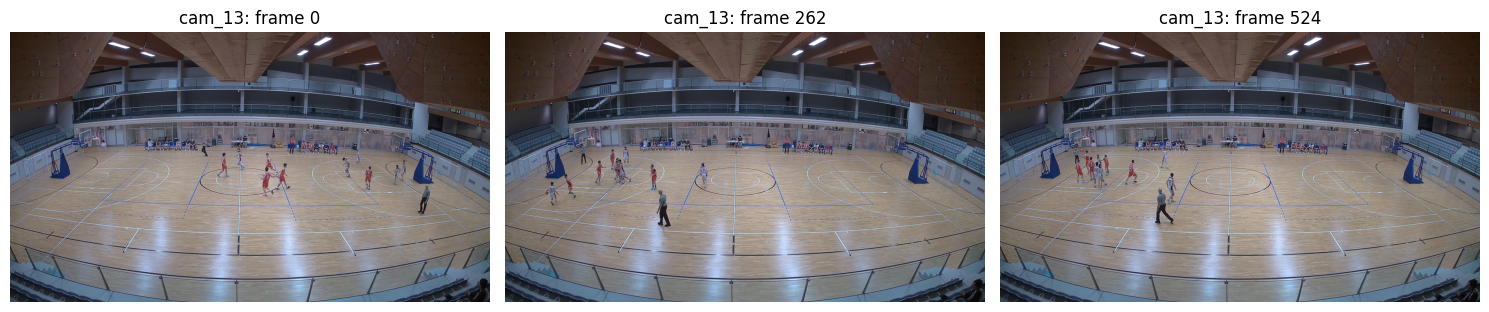

In [6]:
# Show the raw inspect frames once so the reader can see what's being analysed.
show_images(
    [inspect_frames[i] for i in INSPECT_INDEXES],
    titles=[f"{INSPECT_CAMERA_ID}: frame {i}" for i in INSPECT_INDEXES],
)

---

# Detection


---

## Background Subtraction with MOG2 for Player Detection

> Manafifard, M., Ebadi, H., & Abrishami Moghaddam, H. (2017). A survey on player tracking in soccer videos. *Computer Vision and Image Understanding*

Following the survey by Manafifard et al. (2017), we adopt background subtraction as our first detection approach, given its established effectiveness as widely-used baseline before exploring learned-based methods.

Specifically, we use the MOG2 (Mixture of Gaussians v2) background subtractor to detect moving players in each frame.
MOG2 models each pixel's intensity distribution as a mixture of $K$ Gaussian components:

$$P(x_t) = \sum_{k=1}^{K} w_{k,t} \cdot \mathcal{N}(x_t \mid \mu_{k,t}, \sigma_{k,t}^2)$$

A pixel is classified as **foreground** if the Mahalanobis distance to the best-matching background Gaussian exceeds the threshold (VAR_THRESHOLD), otherwise it is **background**.

MOG2 improves over the original MOG in three key ways:
1. **Adaptive parameters**: Weights, means, and variances are updated per-frame using an adaptive learning rate, allowing fast adaptation to slow lighting changes without overreacting to sudden foreground.
2. **Shadow detection**: MOG2 explicitly detects shadowsand marks them as background rather than foreground, reducing false positives from cast shadows on the field.
3. **Better stability**: Multiple Gaussians per pixel better capture multimodal backgrounds (e.g., in our case the spectators), reducing the drift and variance instability present in the original MOG.

Also other methods such as KNN, LSBP and GSOC were tried, but MOG2 was found to be equally effective while being more computationally efficient and simpler, making it a suitable choice for our baseline detection approach.

We further **improved the detection** by applying pre-processing steps and post-processing steps to the frames and the foreground masks, respectively.


For **pre-processing**, we applied a illumination normalization technique called **CLAHE (Contrast Limited Adaptive Histogram Equalization)** to enhance the contrast of the frames, which helps in better foreground detection.

For **post-processing**, we applied morphological operations such as opening and closing to remove noise and fill holes in the detected foreground masks, and then we applied contour detection to extract the bounding boxes of the detected players. We removed small contours that are likely to be noise by filtering based on contour area.

### Parameters

The parameters below were tuned specifically for **cam_13** through empirical experiments. This reveals a fundamental limitation of background subtraction: **the method lacks cross-camera generalization**.

In [7]:
MOG2_LEARNING_RATE  = -1        # -1 lets OpenCV adapt the learning rate automatically
MOG2_HISTORY        = 1000      # number of frames used to model the background
MOG2_VAR_THRESHOLD  = 25        # Mahalanobis distance threshold for foreground/background decision
MOG2_OPENING_KERNEL = 7         # morphological opening kernel size (noise removal)
MOG2_CLOSING_KERNEL = 11        # morphological closing kernel size (hole filling)
MOG2_MIN_AREA       = 1500      # minimum contour area to keep (px²)
MOG2_MAX_AREA       = 200_000   # maximum contour area to keep (px²)

### Run MOG2 Detection on All Frames

For each camera, the code runs MOG2 background subtraction on all frames (using the supplied parameters), producing cleaned foreground masks and measuring elapsed time.
It then converts those masks to a `DetectionOutput` (per-frame bounding boxes + metadata, using the camera’s fps)-


In [8]:
# Streaming MOG2: one BackgroundSubtractorMOG2 per camera carried across chunks
# so the background model keeps its full history without us holding the video
# in RAM. The first `HEAT_UP` frames emit empty detections while the model warms.
HEAT_UP = 10

mog2_masks = {}                # per-inspect-index masks for the inspection camera
mog2_detection_output = {}

_ip_cfg = get_config().detection.image_processing

for cam_id, cam in CAMERAS.items():
    logger.info("[%s] Streaming frames through MOG2...", cam_id)

    # Initialize MOG2 and image processing kernels once per camera
    mog2 = cv2.createBackgroundSubtractorMOG2(
        history=MOG2_HISTORY,
        varThreshold=MOG2_VAR_THRESHOLD,
        detectShadows=False,
    )

    # Create the CLAHE and morphological kernels once per camera since they are reused across frames
    clahe = make_clahe(_ip_cfg.clahe_clip_limit, _ip_cfg.clahe_tile_grid)
    opening_kernel = make_morph_kernel(MOG2_OPENING_KERNEL)
    closing_kernel = make_morph_kernel(MOG2_CLOSING_KERNEL)

    # We will store the MOG2 masks for the inspect camera at the inspect indexes for later visualization
    cam_inspect_masks = {}
    frames_out = []
    nf = total_frames_per_cam[cam_id]
    for start, chunk in stream_frame_chunks(cam.video, chunk_size=CHUNK_SIZE, max_frames=nf):
        for offset, frame in enumerate(chunk):
            fi = start + offset
            mask = step_mog2(
                mog2, frame,
                clahe=clahe,
                opening_kernel=opening_kernel,
                closing_kernel=closing_kernel,
                opening_kernel_size=MOG2_OPENING_KERNEL,
                closing_kernel_size=MOG2_CLOSING_KERNEL,
                min_area=MOG2_MIN_AREA,
                max_area=MOG2_MAX_AREA,
                learning_rate=MOG2_LEARNING_RATE,
                detect_shadows=get_config().detection.mog2.detect_shadows,
            )
            if fi < HEAT_UP:
                # Drop blobs produced before the background model has stabilised.
                frames_out.append(FrameDetections(frame_index=fi, detections=[]))
            else:
                frames_out.append(mog2_frame_to_detections(mask, fi))
            # Store the MOG2 mask for this frame if it's one of the inspect frames for the inspect camera
            if cam_id == INSPECT_CAMERA_ID and fi in INSPECT_INDEXES:
                cam_inspect_masks[fi] = mask

    # Convert the raw frame detections into a DetectionOutput for this camera
    mog2_detection_output[cam_id] = DetectionOutput(
        source="mog2", camera_id=cam_id, fps=fps[cam_id], frames=frames_out,
    )

    # Store the MOG2 masks for the inspect camera so we can visualize them later
    if cam_id == INSPECT_CAMERA_ID:
        mog2_masks[cam_id] = cam_inspect_masks
    n_dets = sum(f.num_detections for f in frames_out)

    # Log the MOG2 results for this camera
    logger.info("[%s] MOG2 done — %d detections across %d frames", cam_id, n_dets, len(frames_out))

01:02:22 | INFO | notebook | [cam_13] Streaming frames through MOG2...
01:09:44 | INFO | notebook | [cam_13] MOG2 done — 3907 detections across 525 frames
01:09:44 | INFO | notebook | [cam_2] Streaming frames through MOG2...
01:17:14 | INFO | notebook | [cam_2] MOG2 done — 3169 detections across 525 frames
01:17:14 | INFO | notebook | [cam_4] Streaming frames through MOG2...
01:25:32 | INFO | notebook | [cam_4] MOG2 done — 5114 detections across 525 frames


### Inspect MOG2 Detections

We visualize the MOG2 blob detected by outputting the binary mask and then the bounding boxes of the detected players. 

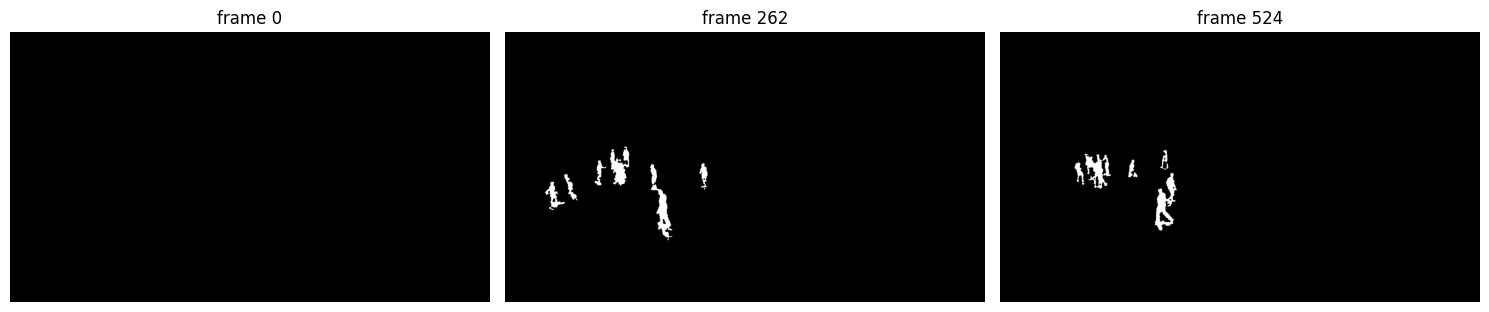

In [9]:
# Show MOG2 masks at the inspect indexes. The frame 0 sample is blank by design
# (it falls inside the MOG2 warm-up window).
show_images(
    [mog2_masks[INSPECT_CAMERA_ID][i] for i in INSPECT_INDEXES],
    titles=[f"frame {i}" for i in INSPECT_INDEXES],
)

Despite MOG2's improvements, several problems are apparent in the detected blobs above:
- **Undetected reflective shadows**: Even with built-in shadow detection, shadows persist on the field because the floor's high reflectivity produces shadows with non-classical hue values. 
- **Shape loss from aggresive morphology**: The morphological operations used to clean the masks can sometimes be too aggressive, leading to loss of parts of the player blobs, especially for players in motion or partially occluded. 
- **Static background assumption**: MOG2 assumes a mostly static background, which is violated in our case due to the presence of moving spectators and dynamic lighting conditions, leading to false positives and missed detections.
- **Static player**: MOG2 relies on motion to detect foreground objects, so players that are static or moving very slowly may not be detected, leading to missed detections during moments of inactivity or slow movement. 
An example could be the second referee.

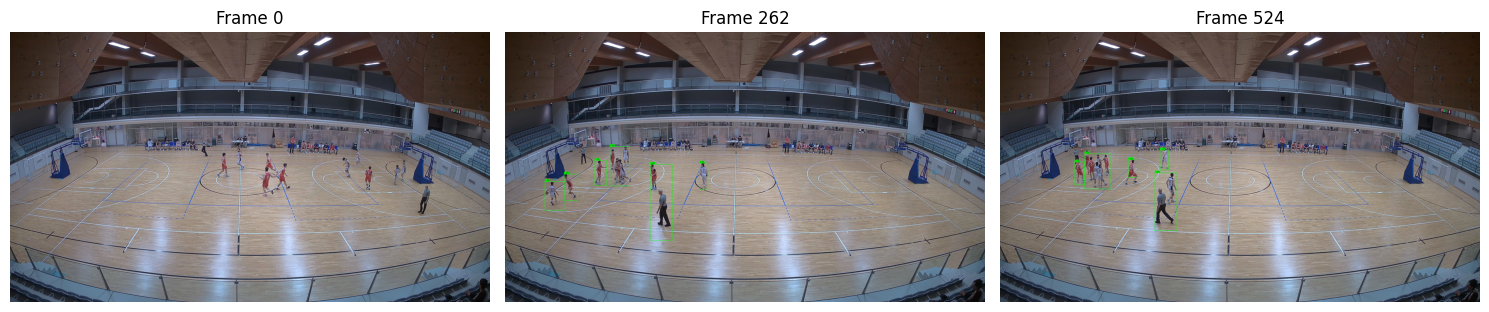

In [10]:
show_inspect(mog2_detection_output[INSPECT_CAMERA_ID])

As expected, these limitations collectively generate **inconsistent and unreliable bounding boxes**, which would lead to poor tracking performance in subsequent steps.

---

## Pre-Trained YOLO26

> Jocher, G., Qiu, J., & Chaurasia, A. (2023). Ultralytics YOLO. 
>
> Joseph Redmon and Santosh Divvala and Ross Girshick and Ali Farhadi. (2016). You Only Look Once: Unified, Real-Time Object Detection.

In order to overcome the limitations of background subtraction, we adopt a deep learning-based object detection approach using the **YOLO26 model**.

YOLO (You Only Look Once) is a family of single-stage, real-time detectors that predict bounding boxes and class probabilities directly from image pixels using a **convolutional backbone** and a detection head. Modern YOLO variants balance accuracy and speed, making them suitable for per-frame video inference.

We choosed a learning-based model because those approaches generalize better across different cameras, viewpoints, and lighting conditions: they learn semantic features (shape, texture, context) that are less sensitive to camera-specific artifacts than background-subtraction heuristics.

We started from a **pre-trained YOLO26 model** in order to leverage the general object detection capabilities it has learned from large-scale datasets, and avoiding to train a model from scratch given the limited size of our dataset. 


### Parameters

The parameters for the YOLO26 model are mostly related to inference settings, such as confidence threshold and non-maximum suppression (NMS) threshold, which control the trade-off between precision and recall in the detections.

In [11]:
YOLO_PRETRAINED_CONF = 0.4    # confidence threshold
YOLO_PRETRAINED_IOU  = 0.45   # IoU threshold for built-in NMS
YOLO_PRETRAINED_SIZE = 640    # inference image size

### Models

In this section we load the `yolo26m.pt` model, which is a medium-sized variant of YOLO26 that offers a good balance between accuracy and inference speed. This model was pre-trained on the COCO dataset, which includes a "person" class that is relevant for our player detection task.

In [12]:
# Resolve the path of pretrained yolo model
MODELS_DIR.mkdir(parents=True, exist_ok=True)
pretrained_yolo_model_path = MODELS_DIR / "yolo26m.pt"

# Load the YOLO26m model (Ultralytics auto-downloads the weights if missing)
pretrained_yolo_model = YOLO(str(pretrained_yolo_model_path))

### Run YOLO Detection on All Frames

As before, we run inference on all frames for each camera, measuring elapsed time and counting detections and outputting the results in a `DetectionOutput` format.

We use YOLO26's built-in `.predict()` method to detect objects in each frame. The output will include bounding boxes, confidence scores, and class labels for each detected object.


In [13]:
yolo_pretrained_detection_output = {}

_yolo_batch = get_config().pipeline.yolo_batch_size

for cam_id, cam in CAMERAS.items():
    logger.info("[%s] Streaming frames through pre-trained YOLO...", cam_id)
    frames_out = []
    nf = total_frames_per_cam[cam_id]
    for start, chunk in stream_frame_chunks(cam.video, chunk_size=CHUNK_SIZE, max_frames=nf):
        # Run yolo detection on the chunk of frames
        raw_chunk = run_yolo_detection(
            pretrained_yolo_model, chunk,
            conf_threshold=YOLO_PRETRAINED_CONF,
            iou_threshold=YOLO_PRETRAINED_IOU,
            inference_size=YOLO_PRETRAINED_SIZE,
            batch_size=_yolo_batch,
        )

        # Convert the raw YOLO chunk output into our DetectionOutput format
        chunk_out = yolo_to_detection_output(
            raw_chunk, pretrained_yolo_model,
            camera_id=cam_id, fps=fps[cam_id], source="yolo26m_pt",
            frame_index_offset=start,
        )
        frames_out.extend(chunk_out.frames)

    # Merge the chunk-level DetectionOutputs into a single DetectionOutput for the whole video
    yolo_pretrained_detection_output[cam_id] = DetectionOutput(
        source="yolo26m_pt", camera_id=cam_id, fps=fps[cam_id], frames=frames_out,
    )

    # Log the YOLO results for this camera
    n_dets = sum(f.num_detections for f in frames_out)
    logger.info("[%s] Pre-trained YOLO done — %d detections across %d frames", cam_id, n_dets, len(frames_out))

01:25:36 | INFO | notebook | [cam_13] Streaming frames through pre-trained YOLO...
01:31:23 | INFO | notebook | [cam_13] Pre-trained YOLO done — 5085 detections across 525 frames
01:31:23 | INFO | notebook | [cam_2] Streaming frames through pre-trained YOLO...
01:37:23 | INFO | notebook | [cam_2] Pre-trained YOLO done — 2538 detections across 525 frames
01:37:23 | INFO | notebook | [cam_4] Streaming frames through pre-trained YOLO...
01:43:39 | INFO | notebook | [cam_4] Pre-trained YOLO done — 4994 detections across 525 frames


### Inspect YOLO Detections

We visualize the YOLO detections by drawing the predicted bounding boxes on the frames and displaying the confidence scores and class labels.

01:43:39 | INFO | notebook | First-frame detections [cam_13]: 11 objects detected
01:43:39 | INFO | notebook |   Detection 1: Class=person, Confidence=0.78, BBox=BoundingBox(x1=3262.9521484375, y1=1217.9407958984375, x2=3361.4716796875, y2=1456.253173828125)
01:43:39 | INFO | notebook |   Detection 2: Class=person, Confidence=0.75, BBox=BoundingBox(x1=1658.1514892578125, y1=961.35791015625, x2=1759.8621826171875, y2=1165.8504638671875)
01:43:39 | INFO | notebook |   Detection 3: Class=person, Confidence=0.74, BBox=BoundingBox(x1=2837.325439453125, y1=1070.1658935546875, x2=2901.689208984375, y2=1265.1837158203125)
01:43:39 | INFO | notebook |   Detection 4: Class=person, Confidence=0.69, BBox=BoundingBox(x1=2107.015869140625, y1=1066.603271484375, x2=2245.59521484375, y2=1281.3424072265625)
01:43:39 | INFO | notebook |   Detection 5: Class=person, Confidence=0.59, BBox=BoundingBox(x1=2005.796630859375, y1=1090.2667236328125, x2=2085.380126953125, y2=1316.70849609375)


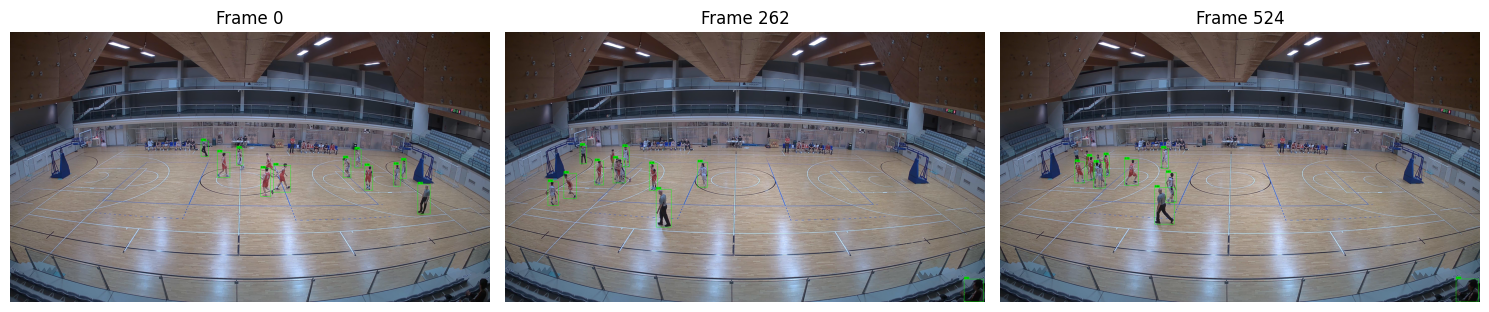

In [14]:
cam = INSPECT_CAMERA_ID
logger.info("First-frame detections [%s]: %d objects detected", cam,
            yolo_pretrained_detection_output[cam].frames[0].num_detections)
for i, det in enumerate(yolo_pretrained_detection_output[cam].frames[0].detections[:5]):
    logger.info("  Detection %d: Class=%s, Confidence=%.2f, BBox=%s",
                i + 1, det.class_name, det.confidence, det.bbox)

show_inspect(yolo_pretrained_detection_output[cam])

As expected, the YOLO detections are much more accurate and consistent than the MOG2 blobs, with fewer false positives and better localization of the players. 

However, we can still observe that is unable to detect the ball, which is a small and fast-moving object that can be easily missed by the model, especially if it is partially occluded or blurred. This highlights the need for further improvements in the detection stage.

Then, the player and referee are detected as `person`, making it impossible to distinguish between them based on the class label alone. This is a common limitation of general object detectors when applied to specific domains.

---

## Fine-Tuned YOLO26

> Jocher, G., Qiu, J., & Chaurasia, A. (2023). Ultralytics YOLO. [`yolo`]
>
> J. Redmon and S. Divvala and R. Girshick and Ali Farhadi. (2016). You Only Look Once: Unified, Real-Time Object Detection.

The pre-trained model delivers reliable bounding box detection for people, but carries fundamental limitations in our domain. To overcome both gaps we **fine-tune** the YOLO26m backbone on other annotated dataset from the same Sanbapolis facility. 

Fine-tuning retains the general visual representations learned at scale (edges, textures, body silhouettes) and replaces the classification head with one trained on our domain-specific class set: one class per player identity (e.g. `Red_11`, `White_7`) and a dedicated `Ball` class. 

However, to address the ball detection gap, we also adopt a **multi-pass inference strategy** that runs two separate passes over each frame at different resolutions and class restrictions.                                             

### Parameters

In [15]:
YOLO_FINETUNED_PLAYER_CONF     = 0.3     # confidence threshold for player pass (high-conf band)
YOLO_FINETUNED_PLAYER_LOW_CONF = 0.15    # low-conf band for DeepSORT ByteTrack pass (< player conf)
YOLO_FINETUNED_BALL_CONF       = 0.2     # lower threshold for ball (small object, favour recall)
YOLO_FINETUNED_PLAYER_SIZE     = 1280    # inference size for player pass
YOLO_FINETUNED_BALL_SIZE       = 1600    # higher resolution for ball pass

### Models

Using a script, we load from **HuggingFace Hub** the fine-tuned model weights, uploaded by us after training on the annotated Sanbapolis dataset. 

In [16]:
# Script to load the fine-tuned YOLO model for player pass detection
yolo_finetuned_model = load_fine_tuned_yolo_model()

01:43:42 | INFO | src.detection.yolo.model | Model ready at /home/blushi/player-tracking-in-sports/models/fine_tuned_models/best.pt. Loading into memory...


### Run Fine-Tuned YOLO Detection on All Frames

As before, we run inference on all frames for each camera, measuring elapsed time and counting detections and outputting the results in a `DetectionOutput` format.


**Higher-Resolution Pass - Ball Only**

At `imgsz = 640`, YOLO26's backbone downsamples a 1080p frame by roughly 1.7×, so a 15 px basketball occupies fewer than two grid cells in the final feature map, far below the **minimum spatial footprint a detection head can reliably localize**.

**Doubling the inference resolution** to 1280 halves the effective downsampling ratio, increasing the grid-cell density dedicated to small objects and giving the head enough spatial signal to produce a confident, well-centred box.

We pair the higher resolution with a lower confidence threshold (0.1 vs. 0.3 for players). 

The ball is frequently motion-blurred, partially occluded, or caught mid-flight at an angle that reduces its visual similarity to the training patches.
Relaxing the threshold recovers these marginal but valid detections at the cost of a modest increase in false positives.


**Merge Player and Ball Detections**

Combine both passes into a single `DetectionOutput`, frame by frame. After fine-tuning, only the `class_ids` lists in the two passes above need to change, the merge stays identical.

**Low-confidence band for tracking.** We run the player pass at a lower threshold (`0.15`) and split the result: detections at or above the main threshold (`0.3`) feed the detection pipeline as usual, while the weaker detections below it are kept aside as a separate low-confidence stream. These are not counted as detections, but are later handed to the tracker's **ByteTrack second pass** to recover players through partial occlusions (see DeepSORT).

In [17]:
yolo_finetuned_merged_output = {}
deepsort_low_conf_detections = {}   # cam_id -> {frame_index: list[Detection]}
_player_classes = list(range(1, len(yolo_finetuned_model.names)))
_yolo_batch = get_config().pipeline.yolo_batch_size
_high_thresh = YOLO_FINETUNED_PLAYER_CONF  # split point between high-conf and low-conf bands

for cam_id, cam in CAMERAS.items():
    logger.info("[%s] Streaming frames through fine-tuned YOLO (player + ball)...", cam_id)
    merged_frames = []
    low_conf_by_frame = {}  # frame_index -> list[Detection]
    nf = total_frames_per_cam[cam_id]
    for start, chunk in stream_frame_chunks(cam.video, chunk_size=CHUNK_SIZE, max_frames=nf):
        # Player pass: run at the low-conf threshold to capture both bands in one YOLO call,
        # then split by confidence. This mirrors run_2D_pipeline._detect_on_chunk.
        raw_player = run_yolo_detection(
            yolo_finetuned_model, chunk,
            conf_threshold=YOLO_FINETUNED_PLAYER_LOW_CONF,
            inference_size=YOLO_FINETUNED_PLAYER_SIZE,
            iou_threshold=get_config().detection.yolo.iou_threshold,
            batch_size=_yolo_batch,
            class_ids=_player_classes,
        )

        # Ball pass inference with YOLO fine-tuned (unchanged)
        raw_ball = run_yolo_detection(
            yolo_finetuned_model, chunk,
            conf_threshold=YOLO_FINETUNED_BALL_CONF,
            inference_size=YOLO_FINETUNED_BALL_SIZE,
            iou_threshold=get_config().detection.yolo.iou_threshold,
            batch_size=_yolo_batch,
            class_ids=[0],
        )

        # Convert the raw YOLO chunk outputs into DetectionOutputs
        all_player_out = yolo_to_detection_output(
            raw_player, yolo_finetuned_model,
            camera_id=cam_id, fps=fps[cam_id], source="yolo26m_ft",
            frame_index_offset=start,
        )
        ball_out = yolo_to_detection_output(
            raw_ball, yolo_finetuned_model,
            camera_id=cam_id, fps=fps[cam_id], source="yolo26m_ft",
            frame_index_offset=start,
        )

        # Split player detections into high-conf (main pipeline) and low-conf (ByteTrack second pass)
        high_conf_frames = []
        for fd in all_player_out.frames:
            high_dets = [d for d in fd.detections if d.confidence >= _high_thresh]
            low_dets  = [d for d in fd.detections if d.confidence <  _high_thresh]
            high_conf_frames.append(FrameDetections(frame_index=fd.frame_index, detections=high_dets))
            if low_dets:
                low_conf_by_frame[fd.frame_index] = low_dets

        player_out = DetectionOutput(
            source=all_player_out.source, camera_id=all_player_out.camera_id,
            fps=all_player_out.fps, frames=high_conf_frames,
        )

        # Merge the high-conf player and ball DetectionOutputs for this chunk
        merged_chunk = merge_detections(player_out, ball_out)
        merged_frames.extend(merged_chunk.frames)

    # Merge the chunk-level DetectionOutputs into a single DetectionOutput for the whole video
    yolo_finetuned_merged_output[cam_id] = DetectionOutput(
        source="yolo26m_ft", camera_id=cam_id, fps=fps[cam_id], frames=merged_frames,
    )
    deepsort_low_conf_detections[cam_id] = low_conf_by_frame

    # Log the YOLO results for this camera
    n_merged = sum(f.num_detections for f in merged_frames)
    n_low    = sum(len(v) for v in low_conf_by_frame.values())
    logger.info("[%s] Fine-tuned YOLO done — %d high-conf + %d low-conf detections across %d frames",
                cam_id, n_merged, n_low, len(merged_frames))

01:43:42 | INFO | notebook | [cam_13] Streaming frames through fine-tuned YOLO (player + ball)...
02:41:45 | INFO | notebook | [cam_13] Fine-tuned YOLO done — 6402 high-conf + 1248 low-conf detections across 525 frames
02:41:45 | INFO | notebook | [cam_2] Streaming frames through fine-tuned YOLO (player + ball)...
03:40:52 | INFO | notebook | [cam_2] Fine-tuned YOLO done — 2671 high-conf + 428 low-conf detections across 525 frames
03:40:52 | INFO | notebook | [cam_4] Streaming frames through fine-tuned YOLO (player + ball)...
04:40:00 | INFO | notebook | [cam_4] Fine-tuned YOLO done — 5603 high-conf + 957 low-conf detections across 525 frames


### Inspect Merged Detections

We visualize the merged detections by drawing the predicted bounding boxes for both players and the ball on the frames, displaying the confidence scores and class labels.

04:40:00 | INFO | notebook | First-frame detections [cam_13]: 13 objects detected
04:40:00 | INFO | notebook |   Detection 1: Class=Red_7, Confidence=0.97, BBox=BoundingBox(x1=2832.412109375, y1=1070.9501953125, x2=2902.647216796875, y2=1264.0196533203125)
04:40:00 | INFO | notebook |   Detection 2: Class=Red_2, Confidence=0.97, BBox=BoundingBox(x1=1656.330078125, y1=968.5979614257812, x2=1761.267822265625, y2=1164.8087158203125)
04:40:00 | INFO | notebook |   Detection 3: Class=White_27, Confidence=0.94, BBox=BoundingBox(x1=2758.51708984375, y1=938.96875, x2=2833.175048828125, y2=1084.9434814453125)
04:40:00 | INFO | notebook |   Detection 4: Class=White_34, Confidence=0.90, BBox=BoundingBox(x1=2661.57861328125, y1=1004.1018676757812, x2=2727.006103515625, y2=1163.5621337890625)
04:40:00 | INFO | notebook |   Detection 5: Class=Refree_2, Confidence=0.90, BBox=BoundingBox(x1=1526.5706787109375, y1=848.166748046875, x2=1586.5433349609375, y2=995.1284790039062)


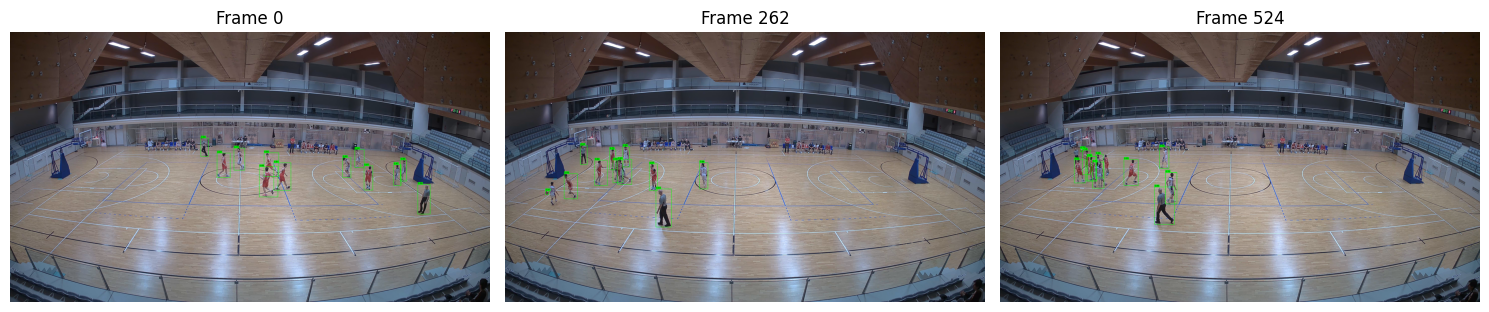

In [18]:
cam = INSPECT_CAMERA_ID
logger.info("First-frame detections [%s]: %d objects detected", cam,
            yolo_finetuned_merged_output[cam].frames[0].num_detections)
for i, det in enumerate(yolo_finetuned_merged_output[cam].frames[0].detections[:5]):
    logger.info("  Detection %d: Class=%s, Confidence=%.2f, BBox=%s",
                i + 1, det.class_name, det.confidence, det.bbox)

show_inspect(yolo_finetuned_merged_output[cam])

As expected, the fine-tuned model delivers much more accurate and consistent detections for both players and the ball, with significantly fewer false positives and better localization.

However, YOLOs **built-in NMS operates independently within each class**.
Because our fine-tuned model encodes player identity directly in the class label (e.g. `Red_5`, `Red_11`), two overlapping boxes predicted for the same physical player but under different class names are treated as entirely distinct objects and both survive suppression. These duplicate boxes would then be handed to the downstream tracker as separate detections, spawning parallel tracks for the same person and fragmenting what should be a single stable identity across multiple track IDs.


---

## Class-Agnostic NMS

> Neubeck, A., & Van Gool, L. (2006). Efficient non-maximum suppression. *ICPR'06*, Vol. 3, 850–855. [`nms`]

Non-Maximum Suppression (NMS) is a standard post-processing step applied after object detection to **eliminate redundant overlapping boxes** for the same physical object.

The algorithm sorts all candidate boxes by confidence score, keeps the highest-scoring box, and suppresses any remaining box whose IoU with it exceeds a threshold $\tau$, repeating until no candidates remain.

To fix the previous issue, we therefore apply a **class-agnostic variant**: the same greedy suppression algorithm, but treating all detections as a single pool regardless of class. 


### Parameters

In [19]:
NMS_IOU_THRESHOLD = 0.75    # IoU above which a lower-confidence box is suppressed

### Run YOLO Detection with Class-Agnostic NMS on All Frames

We take the merged detections from the previous step and apply a class-agnostic NMS to eliminate duplicate boxes for the same physical player, regardless of their predicted class labels.

In [20]:
yolo_finetuned_detection_output = {}
for cam_id in CAMERAS:
    # Log the number of detections before NMS for this camera
    before = sum(len(f.detections) for f in yolo_finetuned_merged_output[cam_id].frames)

    # Apply class-agnostic NMS to the merged YOLO fine-tuned detections for this camera
    yolo_finetuned_detection_output[cam_id] = class_independent_nms(
        yolo_finetuned_merged_output[cam_id], iou_threshold=NMS_IOU_THRESHOLD,
    )
    after = sum(len(f.detections) for f in yolo_finetuned_detection_output[cam_id].frames)

    # Log the NMS results for this camera
    logger.info("[%s] Class-agnostic NMS: %d -> %d detections (%d suppressed)",
                cam_id, before, after, before - after)

04:40:03 | INFO | notebook | [cam_13] Class-agnostic NMS: 6402 -> 5972 detections (430 suppressed)
04:40:03 | INFO | notebook | [cam_2] Class-agnostic NMS: 2671 -> 2450 detections (221 suppressed)
04:40:03 | INFO | notebook | [cam_4] Class-agnostic NMS: 5603 -> 5124 detections (479 suppressed)


### Inspect YOLO Detections with Class-Agnostic NMS

We visualize the final detections after class-agnostic NMS by drawing the predicted bounding boxes on the frames and displaying the confidence scores and class labels.

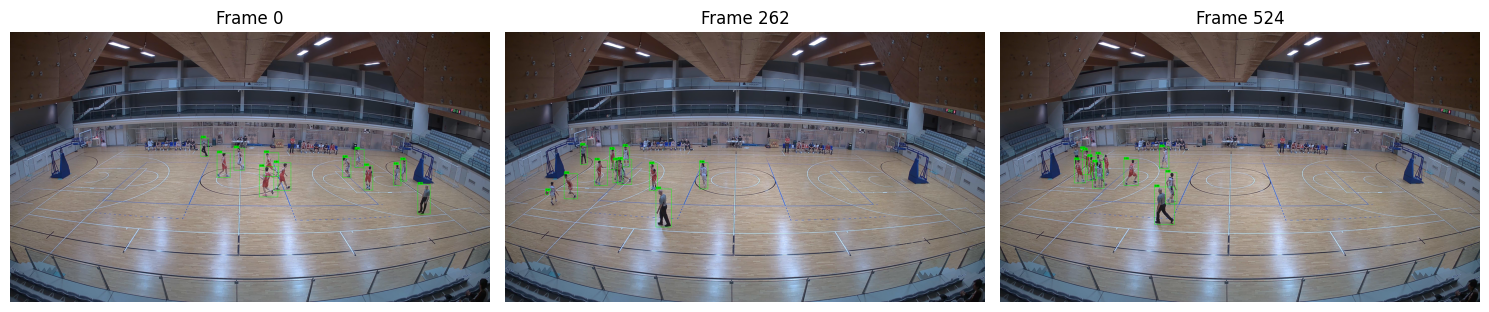

In [21]:
show_inspect(yolo_finetuned_detection_output[INSPECT_CAMERA_ID])

Class-agnostic NMS successfully collapses duplicate boxes for the same physical player, resulting in cleaner detections that are more suitable for tracking. The ball detections remain unaffected since they are distinct objects with their own class label.

We consider this the **final output** of the detection stage, which will be fed into the tracking stage in the next part of the notebook.

---

# Tracking

---

## SORT Tracking

> Bewley, A., Ge, Z., Ott, L., Ramos, F., & Upcroft, B. (2016). Simple online and realtime tracking. *ICIP 2016*, 3464–3468. [`sort`]

SORT (Simple Online and Realtime Tracking) assigns a stable track_id to each detection through a three-step loop executed every frame: **predict**, **match**, **update**.
                                 
Each active track maintains a **Kalman filter** whose state vector encodes bounding-box position and velocity $\mathbf{x} = [u, v, s, r, \dot{u},\dot{v}, \dot{s}]^\top$, where $(u, v)$ is the box centre, $s$ its scale (area), and $r$ the fixed aspect ratio. At the start of each frame the filter propagates every track forward under a constant-velocity motion model, producing a predicted box location even before any detection is observed.

Predicted boxes are then matched to incoming detections using the **Hungarian algorithm** on a cost matrix built from pairwise IoU: detections and predictions with IoU below a minimum threshold are never matched (gating), preventing long-range associations caused by Kalman drift.
Matched tracks absorb their detection as a measurement update, unmatched detections spawn new tentative tracks, and tracks that go unmatched for more than `max_age` frames are killed.


### Parameters

In [22]:
SORT_MAX_IOU_DISTANCE = 0.8   # IoU gating threshold for Kalman-prediction-to-detection assignment
SORT_MAX_AGE          = 60    # frames a track stays alive while unmatched (~2.4 s at 25 fps)
SORT_N_INIT           = 2     # consecutive matches required before a track is confirmed

### Run SORT Tracking on All Frames

We take the final detections from the previous step and feed them into the SORT tracker, performing the **predict-match-update** loop for each frame and outputting a `TrackingOutput` containing the track IDs, bounding boxes, confidence scores, and class labels for each tracked object in each frame.

In [23]:
sort_tracking_output = {}
for cam_id in CAMERAS:
    logger.info("[%s] Running SORT on %d frames...",
                cam_id, len(yolo_finetuned_detection_output[cam_id].frames))
    
    # Apply SORT to the YOLO fine-tuned detections for this camera to produce tracks
    sort_tracking_output[cam_id] = apply_sort(
        yolo_finetuned_detection_output[cam_id],
        max_iou_distance=SORT_MAX_IOU_DISTANCE,
        max_age=SORT_MAX_AGE,
        n_init=SORT_N_INIT,
    )

    # Log the SORT results for this camera
    total_tracks = len({d.track_id for f in sort_tracking_output[cam_id].frames for d in f.detections})
    total_dets   = sum(len(f.detections) for f in sort_tracking_output[cam_id].frames)
    logger.info("[%s] SORT done — %d tracks across %d tracked detections",
                cam_id, total_tracks, total_dets)

04:40:05 | INFO | notebook | [cam_13] Running SORT on 525 frames...
04:40:07 | INFO | notebook | [cam_13] SORT done — 114 tracks across 5642 tracked detections
04:40:07 | INFO | notebook | [cam_2] Running SORT on 525 frames...
04:40:07 | INFO | notebook | [cam_2] SORT done — 63 tracks across 2300 tracked detections
04:40:07 | INFO | notebook | [cam_4] Running SORT on 525 frames...
04:40:09 | INFO | notebook | [cam_4] SORT done — 102 tracks across 4880 tracked detections


### Inspect SORT Tracks

We visualize the final tracks by drawing the predicted bounding boxes for both players and the ball on the frames, displaying the confidence scores, class labels, and track IDs.

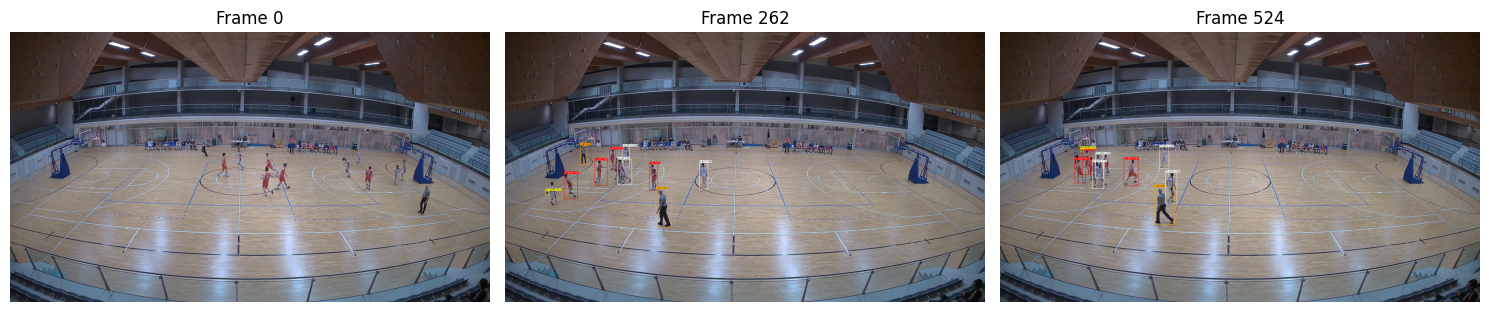

In [24]:
show_inspect(sort_tracking_output[INSPECT_CAMERA_ID])

### Resolve Per-Track Labels

YOLO's class names already encode identity (e.g. `Red_11` = Red team #11), but the model occasionally flips a player's label between frames or returns two boxes with the same class in one frame. We use the track ids assigned above to vote for a stable label per track and resolve collisions where two tracks claim the same identity.

The track with the highest cumulative confidence keeps its top-choice label; any other track that wanted that label falls through to its next-best class. `Ball` is exempt, since it's a category, not a unique identity.

In [25]:
sort_resolved_output = {}
for cam_id in CAMERAS:
    # Resolve the track labels for this camera's SORT output
    sort_resolved_output[cam_id] = resolve_track_labels(sort_tracking_output[cam_id])

    # Analyze the resolved track labels to check for consistency and log any issues
    per_track_label = defaultdict(set)
    for fd in sort_resolved_output[cam_id].frames:
        for d in fd.detections:
            per_track_label[d.track_id].add(d.class_name)

    # Log the number of tracks with a single stable label vs those with multiple labels
    multi_label = [tid for tid, labels in per_track_label.items() if len(labels) > 1]
    logger.info("[%s] Tracks with a single stable label: %d / %d",
                cam_id, len(per_track_label) - len(multi_label), len(per_track_label))
    if multi_label:
        logger.info("  Tracks still showing multiple labels (should only be Ball): %s", multi_label)

04:40:11 | WARNING | src.tracking.label_resolution | track 3 had no free label; keeping conflicting top choice 'White_27'
04:40:11 | WARNING | src.tracking.label_resolution | track 214 had no free label; keeping conflicting top choice 'White_14'
04:40:11 | WARNING | src.tracking.label_resolution | track 133 had no free label; keeping conflicting top choice 'Red_9'
04:40:11 | WARNING | src.tracking.label_resolution | track 11 had no free label; keeping conflicting top choice 'White_16'
04:40:11 | WARNING | src.tracking.label_resolution | track 271 had no free label; keeping conflicting top choice 'Red_9'
04:40:11 | WARNING | src.tracking.label_resolution | track 65 had no free label; keeping conflicting top choice 'Red_11'
04:40:11 | WARNING | src.tracking.label_resolution | track 9 had no free label; keeping conflicting top choice 'Red_23'
04:40:11 | WARNING | src.tracking.label_resolution | track 239 had no free label; keeping conflicting top choice 'Red_2'
04:40:11 | WARNING | src.tr

### Inspect Resolved Tracks

We visualize the final tracks, with resolved labels, by drawing the predicted bounding boxes for both players and the ball on the frames, displaying the confidence scores, class labels, and track IDs.

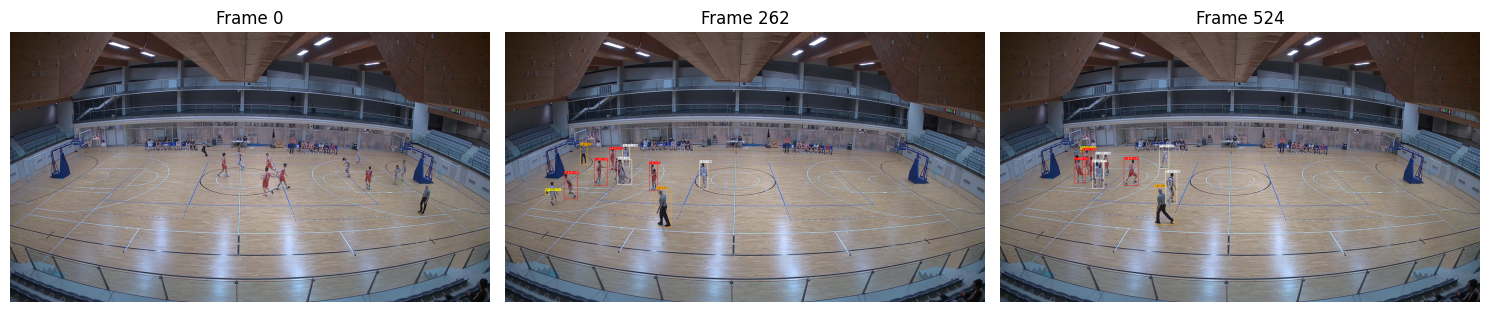

In [26]:
show_inspect(sort_resolved_output[INSPECT_CAMERA_ID])

---

## Tracking with DeepSORT

> Wojke, N., Bewley, A., & Paulus, D. (2017). Simple online and realtime tracking with a deep association metric. *arXiv:1703.07402*. [`deepsort`]
>
> Zhou, K., Yang, Y., Cavallaro, A., & Xiang, T. (2019). Omni-Scale Feature Learning for Person Re-Identification. *arXiv:1905.00953*. [`reid`]

DeepSORT retains the Kalman filter and Hungarian assignment from SORT and **extends** them with a deep appearance metric. 

For each detection, a lightweight **ReID network** (OSNet) extracts a compact embedding from the cropped box region.
Each track maintains a gallery of up to feature_budget past embeddings; the cosine distance between a new detection's embedding and a track's gallery mean is used as a second cost signal alongside IoU.

Matching is performed in a **cascade**: tracks are prioritized by recency (most recently seen first), and appearance distance is the primary gate, IoU is only used as a fallback for tracks that have just been created or that the appearance model is uncertain about. This ordering prevents a long-occluded track from hijacking a detection via a lucky IoU overlap, which is the primary failure mode of SORT during player crossings.

The **practical consequence** in sports footage is significantly fewer identity switches: when two players cross and one is temporarily occluded, the appearance embedding of the re-emerging player pulls the correct track back even if the predicted Kalman box has drifted onto the wrong person.

Our tracker **extends** the original formulation with four robustness mechanisms:
- **NSA Kalman update**: the Kalman measurement noise is scaled by each detection's confidence, so confident boxes correct the state more strongly and uncertain ones move it less, reducing jitter from noisy detections.
- **ByteTrack second pass**: confirmed tracks left unmatched by the appearance cascade are IoU-matched against the **low-confidence** detections set aside during detection, recovering players during partial occlusions without polluting the appearance gallery.
- **Track resurrection (re-ID gallery)**: when a confirmed track dies, its appearance gallery is kept for a few frames; a new detection matching it within a cosine-distance threshold **restores the original track ID** instead of creating a new one, recovering identities lost to longer occlusions.
- **Coasting**: a briefly-unmatched confirmed track still emits its Kalman-predicted box (at zero confidence) to keep a continuous trajectory through short gaps, as long as the prediction stays in-frame and does not overlap an already-matched box.

### Parameters
The parameters below were tuned for sports footage at 25 fps:

- `max_age`: frames a track stays alive while unmatched before being killed. 30 
≈ 1.2 s of occlusion tolerance, too short for basketball where players cross
for 2–3 s. We use 60 (≈ 2.4 s).                                               
- `max_iou_distance`: IoU gating threshold. A looser value (0.8) tolerates more
Kalman drift over longer gaps; too loose causes id swaps between nearby       
players.
- `max_appearance_distance`: cosine distance gate for the OSNet appearance      
embedding. Lower values enforce stricter appearance matching.                 
- `n_init`: consecutive frames a tentative track must match before being
confirmed as active.      

In [27]:
DEEPSORT_MAX_IOU_DISTANCE        = 0.8   # IoU gating. Looser (0.8) tolerates more Kalman drift over
DEEPSORT_MAX_APPEARANCE_DISTANCE = 0.2   # cosine distance threshold for appearance-based matching (lower = stricter, 0.2 is a common default)
DEEPSORT_MAX_AGE                 = 30    # frames a track stays alive while unmatched before being killed. 30 ≈ 1.2 s of occlusion tolerance — too short for football where players cross for 2–3 s. We use 60 (≈ 2.4 s).
DEEPSORT_N_INIT                  = 2     # consecutive matches required before a track is confirmed
DEEPSORT_FEATURE_BUDGET          = 100   # max appearance features stored per track

### Run DeepSORT Tracking on All Frames

We take the final detections from the previous step and feed them into our DeepSORT implementation as before.

In [28]:
deepsort_tracking_output = {}

for cam_id, cam in CAMERAS.items():
    logger.info("[%s] Streaming frames through DeepSORT...", cam_id)

    # Build a DeepSORT tracker for this camera
    tracker = build_deep_sort_tracker(
        max_iou_distance=DEEPSORT_MAX_IOU_DISTANCE,
        max_appearance_distance=DEEPSORT_MAX_APPEARANCE_DISTANCE,
        max_age=DEEPSORT_MAX_AGE,
        n_init=DEEPSORT_N_INIT,
        feature_budget=DEEPSORT_FEATURE_BUDGET,
    )
    det_by_idx = {f.frame_index: f for f in yolo_finetuned_detection_output[cam_id].frames}
    lc_by_idx  = deepsort_low_conf_detections[cam_id]  # ByteTrack low-conf stream

    # Iterate through the video frames in chunks, running DeepSORT on each frame
    tracked_frames = []
    nf = total_frames_per_cam[cam_id]
    for start, chunk in stream_frame_chunks(cam.video, chunk_size=CHUNK_SIZE, max_frames=nf):
        for offset, frame in enumerate(chunk):
            fi = start + offset
            fd = det_by_idx.get(fi)
            if fd is None:
                continue
            # Run a DeepSORT step for this frame, passing low-conf detections for ByteTrack
            tracked_frames.append(
                step_deep_sort(tracker, fd, frame, low_conf_detections=lc_by_idx.get(fi, []))
            )

    # Convert the list of tracked frames into a TrackingOutput for this camera
    deepsort_tracking_output[cam_id] = TrackingOutput(
        source=yolo_finetuned_detection_output[cam_id].source,
        camera_id=cam_id,
        fps=fps[cam_id],
        frames=tracked_frames,
    )

    # Log the DeepSORT results for this camera
    total_tracks = len({d.track_id for f in tracked_frames for d in f.detections})
    total_dets   = sum(len(f.detections) for f in tracked_frames)
    logger.info("[%s] DeepSORT done — %d tracks across %d tracked detections",
                cam_id, total_tracks, total_dets)

04:40:13 | INFO | notebook | [cam_13] Streaming frames through DeepSORT...
04:40:13 | INFO | src.tracking.sort_components.appearance | Loading OSNet model osnet_x1_0 from /home/blushi/player-tracking-in-sports/models/osnet_x1_0_msmt17.pt onto cpu...
05:15:08 | INFO | notebook | [cam_13] DeepSORT done — 98 tracks across 6986 tracked detections
05:15:08 | INFO | notebook | [cam_2] Streaming frames through DeepSORT...
05:15:08 | INFO | src.tracking.sort_components.appearance | Reusing cached OSNet model from /home/blushi/player-tracking-in-sports/models/osnet_x1_0_msmt17.pt.
05:29:53 | INFO | notebook | [cam_2] DeepSORT done — 54 tracks across 2792 tracked detections
05:29:53 | INFO | notebook | [cam_4] Streaming frames through DeepSORT...
05:29:53 | INFO | src.tracking.sort_components.appearance | Reusing cached OSNet model from /home/blushi/player-tracking-in-sports/models/osnet_x1_0_msmt17.pt.
05:59:59 | INFO | notebook | [cam_4] DeepSORT done — 92 tracks across 5768 tracked detections

### Inspect DeepSORT Tracks

We visualize the final tracks by drawing the predicted bounding boxes for both players and the ball on the frames, displaying the confidence scores, class labels, and track IDs.

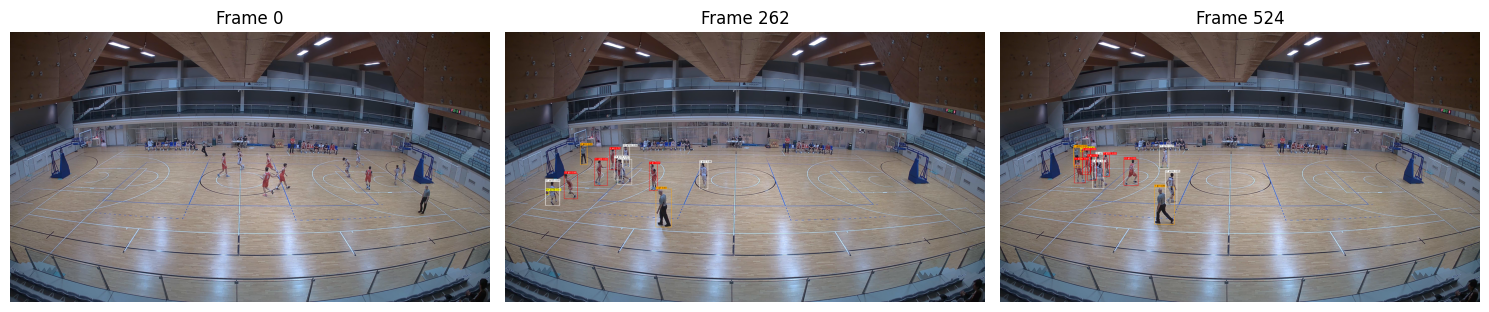

In [29]:
show_inspect(deepsort_tracking_output[INSPECT_CAMERA_ID])

### Smooth 2D Trajectories

Before resolving labels, we apply lightweight temporal smoothing to the 2D tracks: short gaps (≤ `max_gap` frames) where a track briefly went undetected are **linearly interpolated**, then each track's box corners pass through an **exponential moving average** to damp frame-to-frame jitter, yielding steadier inputs for label resolution and 3D reconstruction.

### Parameters

In [30]:
TRAJECTORY_SMOOTH_MAX_GAP   = 5    # max consecutive frames without a real detection that will be linearly interpolated (longer gaps left as-is)
TRAJECTORY_SMOOTH_EMA_ALPHA = 0.5  # EMA weight in [0, 1]; 1.0 = no smoothing, lower = more smoothing

### Running Smooth 2D Trajectories

In [31]:
# Apply 2D trajectory smoothing before label resolution, mirroring run_2D_pipeline.py
deepsort_tracking_output = {
    cam_id: smooth_tracking_output(
        deepsort_tracking_output[cam_id],
        max_gap=TRAJECTORY_SMOOTH_MAX_GAP,
        ema_alpha=TRAJECTORY_SMOOTH_EMA_ALPHA,
    )
    for cam_id in CAMERAS
}
logger.info("Smoothed 2D DeepSORT trajectories (gap-fill <= %d frames + EMA alpha=%.2f)",
            TRAJECTORY_SMOOTH_MAX_GAP, TRAJECTORY_SMOOTH_EMA_ALPHA)

06:00:01 | INFO | notebook | Smoothed 2D DeepSORT trajectories (gap-fill <= 5 frames + EMA alpha=0.50)


### Resolve Per-Track Labels

As with SORT, we use the track ids assigned above to vote for a stable label per track and resolve collisions where two tracks claim the same identity.

In [32]:
deepsort_resolved_output = {}
for cam_id in CAMERAS:
    deepsort_resolved_output[cam_id] = resolve_track_labels(deepsort_tracking_output[cam_id])

    per_track_label = defaultdict(set)
    for fd in deepsort_resolved_output[cam_id].frames:
        for d in fd.detections:
            per_track_label[d.track_id].add(d.class_name)

    multi_label = [tid for tid, labels in per_track_label.items() if len(labels) > 1]
    logger.info("[%s] Tracks with a single stable label: %d / %d",
                cam_id, len(per_track_label) - len(multi_label), len(per_track_label))
    if multi_label:
        logger.info("  Tracks still showing multiple labels (should only be Ball): %s", multi_label)

06:00:01 | WARNING | src.tracking.label_resolution | track 3 had no free label; keeping conflicting top choice 'White_27'
06:00:01 | WARNING | src.tracking.label_resolution | track 8 had no free label; keeping conflicting top choice 'White_14'
06:00:01 | WARNING | src.tracking.label_resolution | track 32 had no free label; keeping conflicting top choice 'White_16'
06:00:01 | WARNING | src.tracking.label_resolution | track 58 had no free label; keeping conflicting top choice 'Red_11'
06:00:01 | WARNING | src.tracking.label_resolution | track 155 had no free label; keeping conflicting top choice 'Red_9'
06:00:01 | WARNING | src.tracking.label_resolution | track 18 had no free label; keeping conflicting top choice 'Red_23'
06:00:01 | WARNING | src.tracking.label_resolution | track 244 had no free label; keeping conflicting top choice 'White_27'
06:00:01 | WARNING | src.tracking.label_resolution | track 222 had no free label; keeping conflicting top choice 'White_16'
06:00:01 | WARNING | s

### Inspect Resolved Labels

We visualize the final tracks, with resolved labels, by drawing the predicted bounding boxes for both players and the ball on the frames, displaying the confidence scores, class labels, and track IDs.

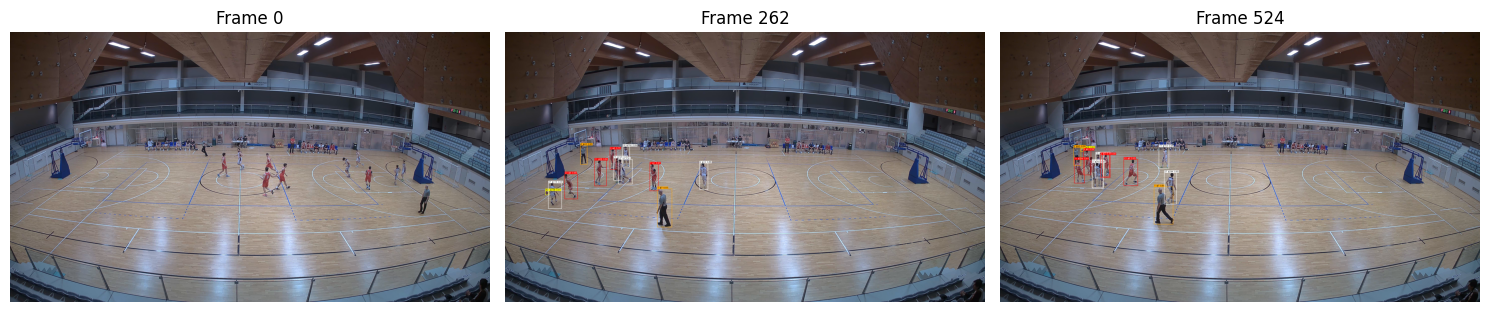

In [33]:
show_inspect(deepsort_resolved_output[INSPECT_CAMERA_ID])

---

# 3D Reconstruction

After obtaining the multi-view tracking results, we can perform 3D reconstruction of player and ball positions using the multiple camera views and the known parameters of the cameras. This involves triangulating the 2D detections from each camera to estimate the 3D coordinates of the players and the ball in the world space. 


We will consider the tracking output from **YOLO + DeepSORT** tracker as the input for the 3D reconstruction step.

---


### Load Camera Calibration Data

We note that the **extrinsic parameters** of the cameras are not provided, but we compute them with the script `scripts/compute_extrinsics.py` using the known **intrinsic parameters**.

For each camera, the script asks us to click several known court landmarks on the first frame and pairs those 2D image points with their fixed 3D coordinates in the court model. It then solves the camera pose, recovering the rotation and translation vectors that map the court coordinate system into the image. 

The solver automatically models lens distortion directly (the image is not pre‑undistorted).

In [34]:
# Load camera calibration data for triangulation cameras only
cameras_settings = {cam_id: CameraData.load(cam_id, base_dir=CAMERA_DATA_DIR) for cam_id in CAMERAS}

---

## Triangulation

We first **rectify** the tracking output using the camera settings recovered above, which removes lens distortion and maps each detection's reference pixel into a common (undistorted) coordinate system. The reference pixel is **class-aware**: the ball uses its bounding-box **centre**, players use their **bottom-centre**, the ground-contact point, so they can be placed on the court floor.

We then reconstruct each entity's 3D position per frame, matching detections across the three cameras by shared **class_id** and **frame_index**. Players and the ball are handled differently:
- **Players** are assumed to stand on the court plane (**Z = 0**): each camera's bottom-centre pixel is back-projected to a 3D ray and intersected with the floor, and the per-camera ground estimates are robustly combined (median-inlier averaging), which also lets a position be recovered from a single camera.
- **The ball** is airborne, so it is triangulated freely in 3D: the per-camera projection matrices (from intrinsics and extrinsics) are stacked into a linear system solved by **SVD** (DLT), with views whose reprojection error is too large discarded before a final solve.

In [35]:
rectified_tracking_output = {
    cam_id: rectify_tracking_output(deepsort_resolved_output[cam_id], cameras_settings[cam_id])
    for cam_id in CAMERAS
}

# Triangulate rectified 2D points from multiple cameras into 3D world coordinates
triangulated_output = triangulate_rectified_outputs(cameras_settings, rectified_tracking_output)

logger.info("3D Reconstruction: %d frames, cameras: %s",
            len(triangulated_output.frames), triangulated_output.camera_ids)
logger.info("Points per frame (sample): %s",
            [len(f.points) for f in triangulated_output.frames[:5]])

06:00:05 | INFO | notebook | 3D Reconstruction: 525 frames, cameras: ['cam_13', 'cam_2', 'cam_4']
06:00:05 | INFO | notebook | Points per frame (sample): [0, 12, 12, 12, 12]


### Inspect 3D Reconstructions

We take the triangulated 3D points for each player and the ball and visualize them in a 3D plot, showing their trajectories over time.

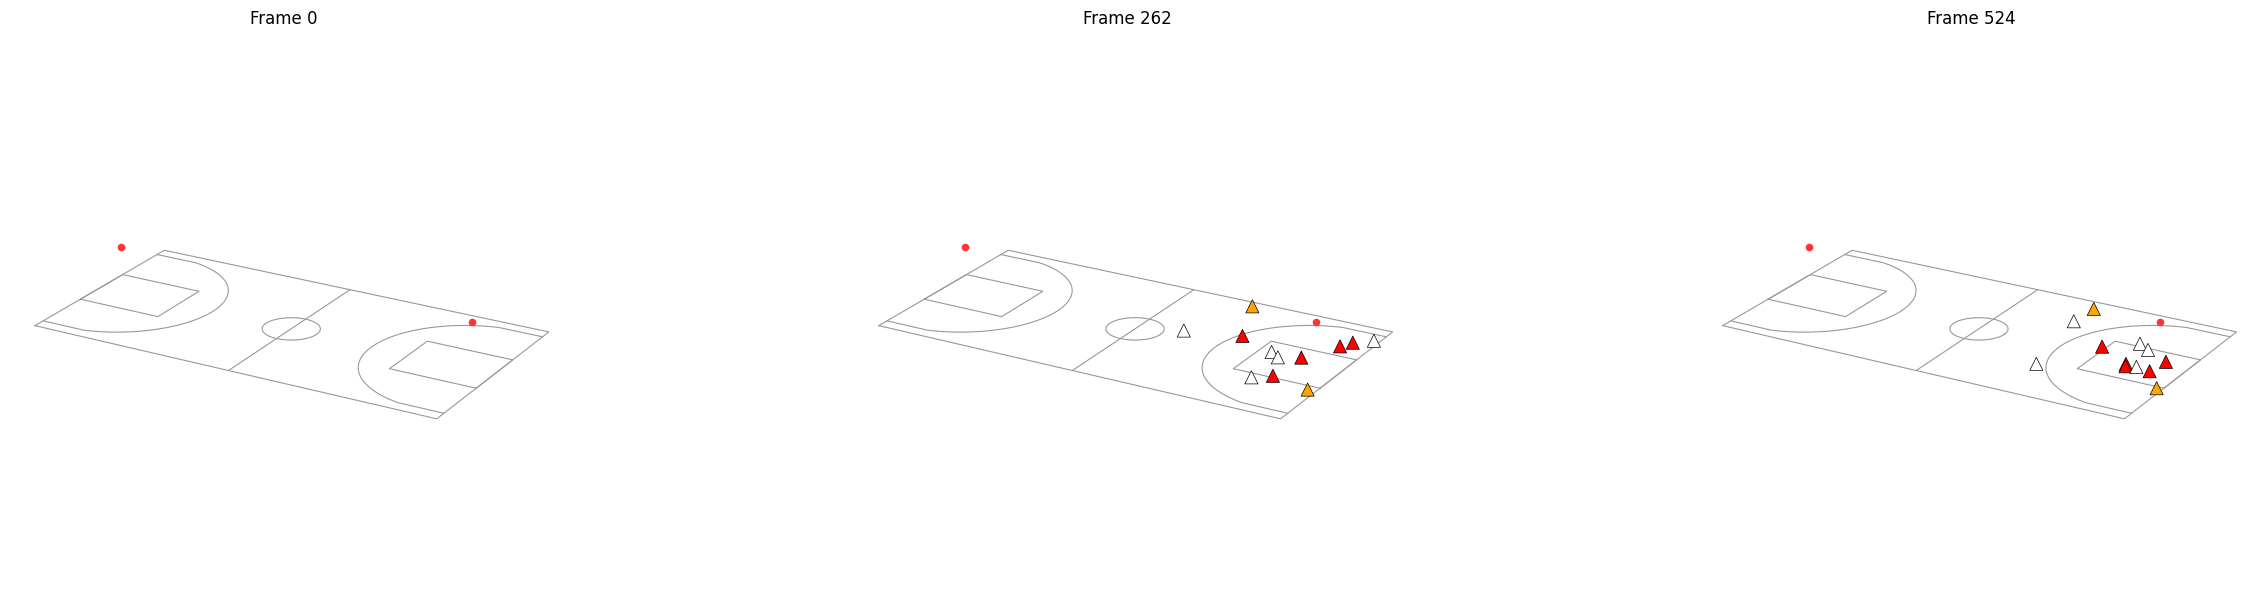

In [36]:
show_3d_scene_frames(triangulated_output)

## Smoothing

Smoothing runs a **Kalman filter with an RTS (Rauch–Tung–Striebel) backward pass** per tracked entity, estimating both position and velocity. A forward filtering pass is followed by a backward smoothing pass, so each point is corrected using both past and future observations; a **chi-square gate** rejects outlier measurements, and trajectories are split wherever the gap between observations exceeds `max_gap`.

This mitigates the noise and jitter in the triangulated 3D points, caused by detection errors, occlusions, and triangulation inaccuracies.

### Parameters

In [37]:
SMOOTH_3D_STD_POS  = 30.0   # Kalman process noise: position std (mm)
SMOOTH_3D_STD_VEL  = 60.0   # Kalman process noise: velocity std (mm/frame)
SMOOTH_3D_STD_MEAS = 80.0   # Kalman measurement noise std (mm)

### Smoothing 3D Trajectories

In [38]:
# Apply temporal smoothing to the triangulated 3D
triangulated_output = smooth_triangulation(
    triangulated_output,
    std_pos=SMOOTH_3D_STD_POS,
    std_vel=SMOOTH_3D_STD_VEL,
    std_meas=SMOOTH_3D_STD_MEAS,
)

### Inspect Smoothed 3D Reconstructions

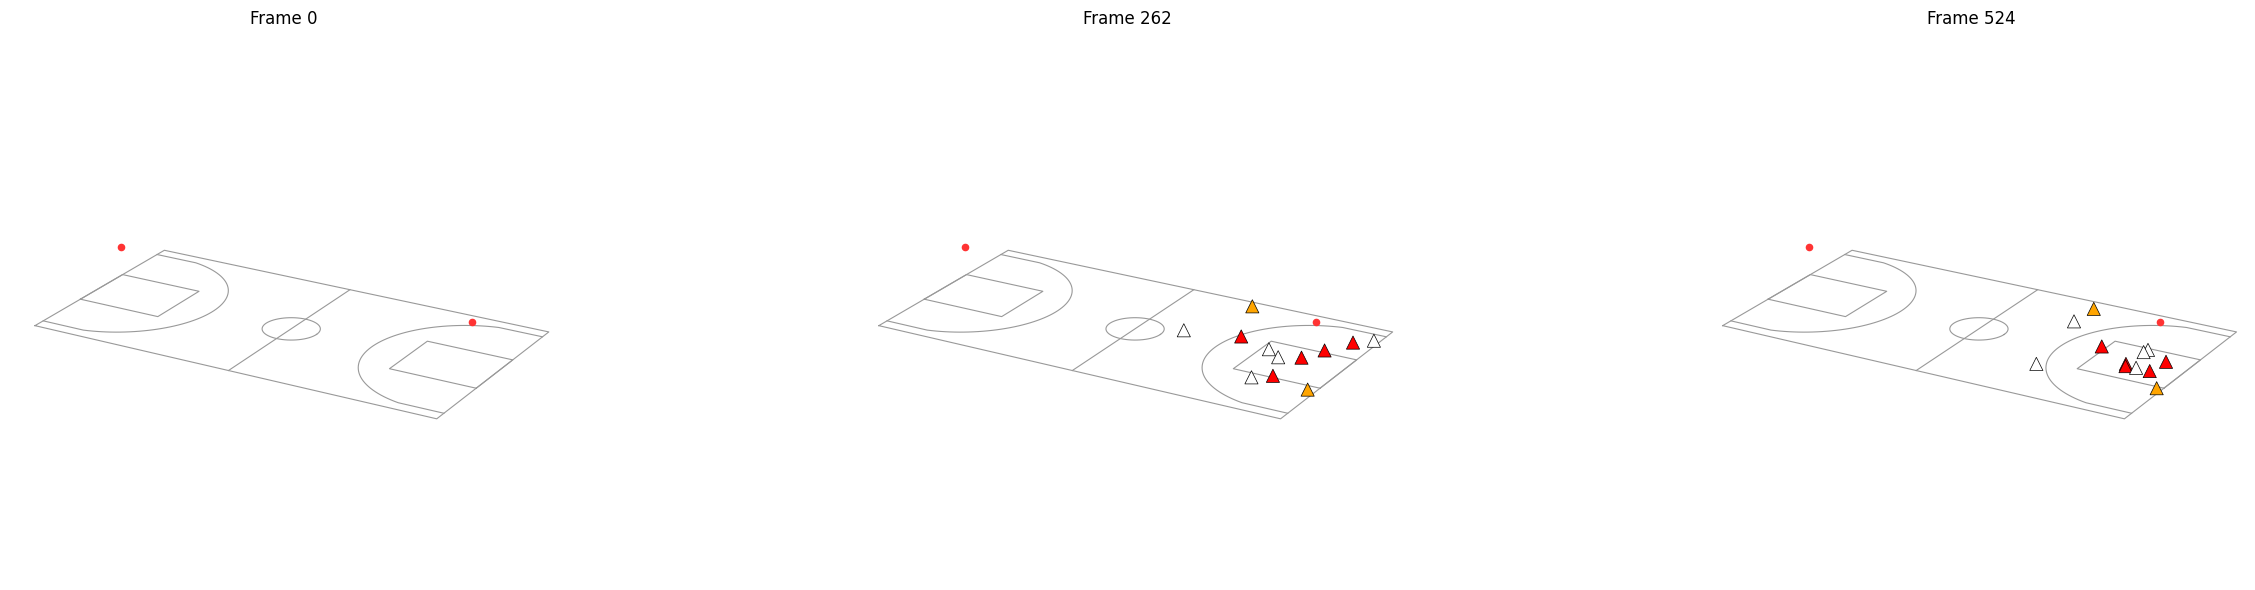

In [39]:
show_3d_scene_frames(triangulated_output)

---

# Evaluation

---

## Ground Truth

The code downloads annotations from Roboflow (if not already cached locally) using an API key stored in `.env`, extracts them into `ANNOTATIONS`, and loads one `DetectionOutput` per camera that the evaluators will use as the reference signal.

Ground truth annotations are **sparse**: the dataset provides bounding boxes every `FRAME_STRIDE` frames (every 5 frames at 25 fps). Both the detection and tracking evaluators receive `frame_stride` as a parameter and use it to align predicted frames with annotated frames, skipping non-annotated frames entirely. This ensures metrics are computed only where ground truth exists, avoiding artificial false positives on unannotated frames.

In [40]:
annotations_root = ANNOTATIONS_DIR / ANNOTATIONS_VERSION
if not any(annotations_root.glob("*.json")):
    load_dotenv()
    api_key = os.environ["ANNOTATIONS_API_KEY"]
    download_annotations("tracking-rybv7", ANNOTATIONS_VERSION, 1, api_key, str(ANNOTATIONS_DIR))
else:
    logger.info("Annotations already present in %s — skipping download.", annotations_root)

# Load annotations for each camera and print summary
ground_truth = {}
for cam_id in CAMERAS:
    ground_truth[cam_id] = load_annotations(camera_id=cam_id, version=ANNOTATIONS_VERSION)
    n_ann = sum(len(f.detections) for f in ground_truth[cam_id].frames)
    logger.info("[%s] Loaded %d annotations across %d frames",
                cam_id, n_ann, len(ground_truth[cam_id].frames))

06:00:07 | INFO | notebook | Annotations already present in /home/blushi/player-tracking-in-sports/data/annotations/tracking_01 — skipping download.
06:00:07 | INFO | notebook | [cam_13] Loaded 1408 annotations across 105 frames
06:00:07 | INFO | notebook | [cam_2] Loaded 544 annotations across 105 frames
06:00:07 | INFO | notebook | [cam_4] Loaded 1143 annotations across 105 frames


---

## Detection

Detection metrics are computed at the bounding-box level, ignoring identity. A predicted box is a **True Positive (TP)** when its IoU with an unmatched ground-truth box meets or exceeds 0.5; otherwise it is a **False Positive (FP)**. A ground-truth box with no matching prediction is a **False Negative (FN)**.

**IoU (Intersection over Union)** is the area of overlap between the predicted box and the ground-truth box divided by the area of their union. A **common threshold** for considering a detection correct is IoU ≥ 0.5.

$$\text{IoU}(A, B) = \frac{A \cap B}{A \cup B}$$

Where $A$ is the predicted bounding box and $B$ is the ground-truth bounding box.

**Precision** measures what fraction of all predictions are actually correct:

$$\text{Precision} = \frac{TP}{TP + FP}$$

**Recall** measures what fraction of all ground-truth objects were found:

$$\text{Recall} = \frac{TP}{TP + FN}$$

**F1** is the harmonic mean of precision and recall, penalising any imbalance between the two, a detector that achieves one at the expense of the other will score poorly:

$$F_1 = \frac{2 \cdot TP}{2 \cdot TP + FP + FN}$$

**Mean IoU** is the average spatial overlap of matched TP pairs. It is independent of precision and recall and quantifies how tightly predicted boxes are localised around the ground truth.

In [41]:
# Evaluate detection performance of MOG2, pre-trained YOLO, and fine-tuned YOLO against ground truth annotations
detection_results = {}
for method_name, outputs in [
    ("MOG2",             mog2_detection_output),
    ("YOLO pre-trained", yolo_pretrained_detection_output),
    ("YOLO fine-tuned",  yolo_finetuned_detection_output),
]:
    for cam_id in CAMERAS:
        detection_results[(method_name, cam_id)] = evaluate_detection(
            ground_truth[cam_id], outputs[cam_id], frame_stride=FRAME_STRIDE,
        )

# Display detection results in a table
show_detection_table(detection_results)

TP   FP    FN  Precision  Recall     F1  Mean IoU
Method           Camera                                                    
MOG2             cam_13  156  414  1039      0.471   0.262  0.337     0.651
                 cam_2   110  422   322      0.345   0.408  0.374     0.663
                 cam_4   107  687   808      0.328   0.293  0.309     0.700
YOLO pre-trained cam_13  233  168   561      0.834   0.602  0.699     0.748
                 cam_2   163   94   119      0.819   0.781  0.800     0.785
                 cam_4   168   73   221      0.927   0.807  0.862     0.808
YOLO fine-tuned  cam_13  173  152   377      0.872   0.732  0.796     0.758
                 cam_2   133   82   130      0.835   0.761  0.796     0.757
                 cam_4   140   78   203      0.923   0.822  0.870     0.796

---

## Tracking

> Luiten, J., et al. (2020). HOTA: A Higher Order Metric for Evaluating Multi-object Tracking. *IJCV*, 129(2), 548–578. [`hota`]

Tracking evaluation uses two complementary metric families on top of the detection scores above.


In [42]:
# Evaluate tracking performance of SORT and DeepSORT against ground truth annotations
tracking_results = {}
for tracker_name, outputs in [
    ("SORT",     sort_resolved_output),
    ("DeepSORT", deepsort_resolved_output),
]:
    for cam_id in CAMERAS:
        tracking_results[(tracker_name, cam_id)] = evaluate_tracking(
            ground_truth[cam_id], outputs[cam_id], frame_stride=FRAME_STRIDE,
        )

### Identity Metrics

IDF1 measures how well predicted tracks maintain the correct identity over time. Detections are matched by IoU (threshold 0.5) and identity is compared between GT `class_name` and predicted `track_id`.

- **IDTP**: GT detections correctly matched to a prediction of the same identity.
- **IDFP**: predictions matched to a GT box of a different identity, or with no GT match.
- **IDFN**: GT detections matched to a prediction of a different identity, or with no prediction match.
- **IDP / IDR / IDF1**: ID precision, recall, and their harmonic mean.

In [43]:
show_identity_table(tracking_results)

TP   FP   FN    IDP    IDR   IDF1
Tracker  Camera                                    
SORT     cam_13  724  373  684  0.660  0.514  0.590
         cam_2   330  114  214  0.743  0.607  0.668
         cam_4   692  209  451  0.768  0.605  0.679
DeepSORT cam_13  750  526  658  0.588  0.533  0.569
         cam_2   328  204  216  0.617  0.603  0.610
         cam_4   692  341  451  0.670  0.605  0.638

### HOTA Metrics

HOTA decomposes overall tracking quality into independent detection and association components, evaluated at multiple IoU thresholds $\alpha \in \{0.05, 0.10, \dots, 0.95\}$.

**Detection accuracy** at threshold $\alpha$ is the IoU over all detections it rewards finding objects and penalises both missed and spurious boxes:

$$\text{DetA}(\alpha) = \frac{TP(\alpha)}{TP(\alpha) + FP(\alpha) + FN(\alpha)}$$

**Association accuracy** measures how well matched detections are linked into consistent tracks. For each matched ground-truth–prediction pair $(c, \hat{c})$, it computes a per-pair IoU over all frames where that pair is active and averages across all matched pairs:

$$\text{AssA}(\alpha) = \frac{1}{|TP(\alpha)|} \sum_{(c,\,\hat{c})\,\in\, TP(\alpha)} \frac{|TPA(c,\hat{c})|}{|TPA(c,\hat{c})| + |FPA(c,\hat{c})| + |FNA(c,\hat{c})|}$$

where $TPA$, $FPA$, $FNA$ count frames where the pair is correctly associated, incorrectly associated, or missed respectively. **HOTA** at a single threshold is the geometric mean of the two, ensuring neither component can dominate:

$$\text{HOTA}(\alpha) = \sqrt{\text{DetA}(\alpha) \times \text{AssA}(\alpha)}$$

The final score is averaged uniformly across all thresholds, preventing a detector that is strong at loose IoU from masking poor localisation at strict thresholds:

$$\text{HOTA} = \frac{1}{|\mathcal{A}|} \sum_{\alpha \,\in\, \mathcal{A}} \text{HOTA}(\alpha)$$

**LocA** is the mean IoU of all matched pairs across thresholds, summarising spatial localisation quality independently of association.

In [44]:
show_hota_table(tracking_results)

HOTA   DetA   AssA   LocA
Tracker  Camera                            
SORT     cam_13  0.438  0.484  0.398  0.797
         cam_2   0.517  0.515  0.522  0.794
         cam_4   0.542  0.575  0.514  0.829
DeepSORT cam_13  0.434  0.469  0.405  0.769
         cam_2   0.480  0.453  0.511  0.761
         cam_4   0.521  0.553  0.495  0.798

---

## 3D Reconstruction Evaluation

We evaluate 3D geometry quality by projecting the triangulated output back into each camera's image plane and comparing against the GT annotated 2D positions.

For each camera two metric families are computed:
- **ReprojectionMetrics**: how accurately each triangulated 3D point back-projects onto the 2D detection that was used as its triangulation input.
- **TrajectoryMetrics**: how well the projected per-identity trajectories match the GT annotated trajectories over time.

All errors below are reported in **millimeters**: each image-plane pixel error is scaled by $Z/f$ (the point's camera-frame depth over the focal length), making the metrics comparable across cameras and resolutions.

We rectify the ground-truth annotations using camera calibration to remove lens distortion, producing `rectified_ground_truth`, so trajectory evaluation uses a coordinate system consistent with the reconstruction step (ball by centre, players by bottom-centre).

In [45]:
rectified_ground_truth = {
    cam_id: rectify_tracking_output(ground_truth[cam_id], cameras_settings[cam_id])
    for cam_id in CAMERAS
}

Then, we perform the evaluation.

In [46]:
geometry_results = evaluate_geometry(
    triangulations = triangulated_output,
    rectified_tracking = rectified_tracking_output,
    rectified_annotated_tracking = rectified_ground_truth,
    frame_stride = FRAME_STRIDE,
)

### Reprojection Metrics

A triangulated 3D point is projected into pixel space via $\mathbf{p} = K [R \mid t]\, \mathbf{P}_w$ and compared to the 2D detection that was its triangulation input:

$$e = \bigl\|\hat{\mathbf{p}} - \mathbf{p}_{\text{pred}}\bigr\|_2 \cdot \frac{Z}{f}$$

The pixel residual is scaled to a physical distance by $Z/f$, where $Z$ is the point's camera-frame depth and $f=(f_x+f_y)/2$ the focal length, so the error is expressed in **millimeters** at the object's depth.

- **Mean / Median / Std / RMSE**: distribution of reprojection errors (mm) across all matched identity–frame pairs.
- **Accuracy @ N mm**: fraction of matches with error below 25 / 50 / 100 mm.

In [47]:
show_reprojection_table(geometry_results)

,Mean (px),Median (px),RMSE (px),Std (px),Acc @ 5px,Acc @ 10px,Acc @ 20px
Camera,,,,,,,
cam_13,51.33,28.88,87.72,71.13,0.135,0.221,0.349
cam_2,140.03,94.47,278.71,240.98,0.028,0.047,0.094
cam_4,135.04,49.96,296.23,263.66,0.168,0.214,0.295


### Trajectory Metrics

Per-identity predicted trajectories (projected from 3D) are compared against GT annotated 2D trajectories at each shared GT frame; each per-frame pixel displacement is scaled by $Z/f$ to a physical distance, so the errors are in **millimeters**.

- **ADE** (Average Displacement Error): mean Euclidean distance between GT and predicted positions over all shared frames.
- **FDE** (Final Displacement Error): Euclidean distance at the last shared frame; captures long-term drift.
- **MTE** (Median Trajectory Error): median per-frame displacement, robust to outlier frames.
- **Fragments**: number of coverage gaps in the predicted trajectory relative to GT.

In [48]:
show_trajectory_table(geometry_results)

,ADE (px),FDE (px),MTE (px),Trajs,Fragments
Camera,,,,,
cam_13,976.77,849.78,1047.51,13,2
cam_2,1066.02,1279.10,1181.44,11,5
cam_4,1838.24,1689.12,1899.96,13,5
